# Models for Outcomes

In [1]:
import pandas as pd
import xarray as xr
import xgboost as xgb
import numpy as np
from pathlib import Path
import seaborn as sns
import os
import json
from IPython.display import display, JSON

## Non-extreme outcomes

For modelling relationships between covariates and the average of the outcome variable among all ARs, we use the `xgboost` algorithm and assess variable importance via partial dependence plots at SHAP values.

### Round 1: Snow

In [83]:
with open('rounds/snow_round1_hyperparams.json', 'r') as f:
    json_data = json.load(f)

display(JSON(json_data))

<IPython.core.display.JSON object>

In [102]:
round1_snow = pd.read_csv('rounds/snow_xgb_round1.csv', index_col=False)

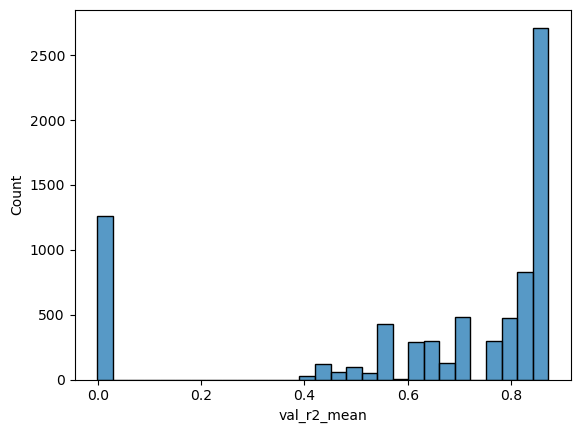

In [52]:
sns.histplot(data=round1_snow, x='val_r2_mean');

Seems like `min_child_weight` being $1000$ is too big; the trees aren't building at all, so $R^{2}$ is essentially 0.

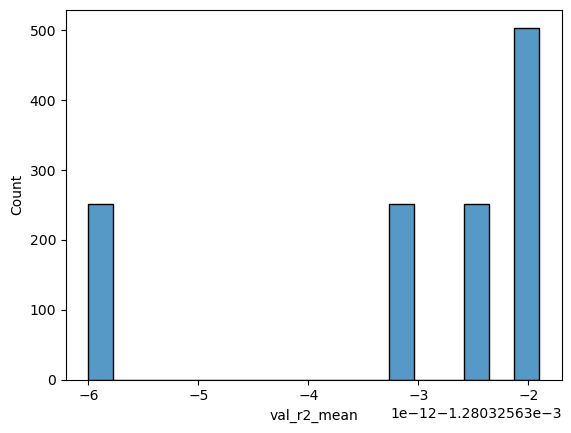

In [53]:
sns.histplot(data=round1_snow[round1_snow.min_child_weight == 1000], x='val_r2_mean');

Seems like $500$ is also too big.

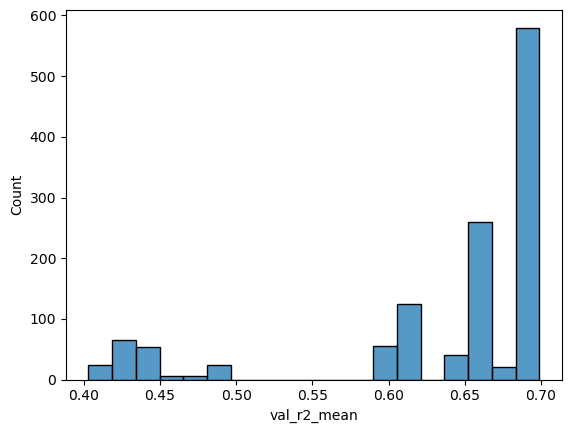

In [58]:
sns.histplot(data=round1_snow[round1_snow.min_child_weight == 500], x='val_r2_mean');

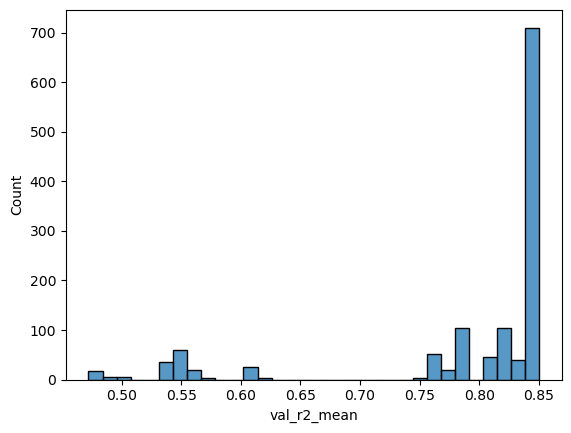

In [59]:
sns.histplot(data=round1_snow[round1_snow.min_child_weight == 100], x='val_r2_mean');

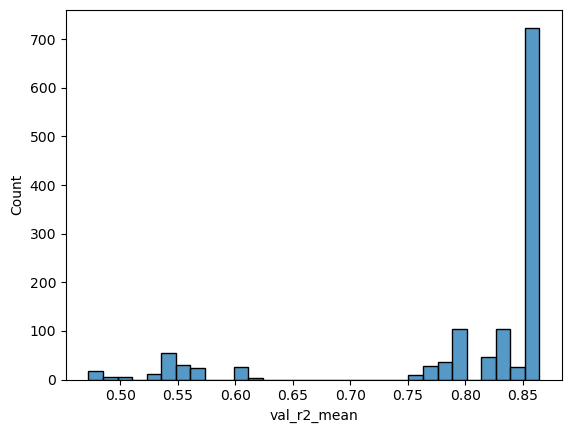

In [60]:
sns.histplot(data=round1_snow[round1_snow.min_child_weight == 50], x='val_r2_mean');

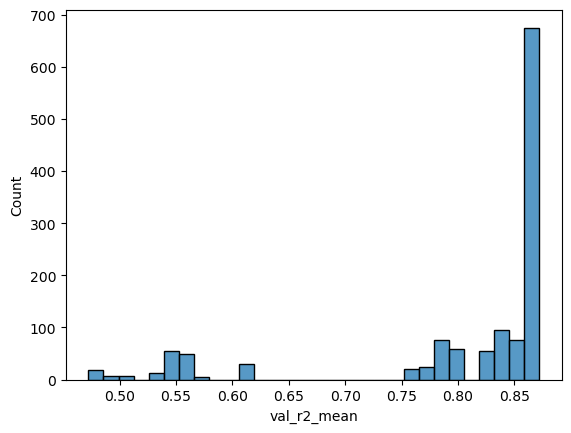

In [61]:
sns.histplot(data=round1_snow[round1_snow.min_child_weight == 10], x='val_r2_mean');

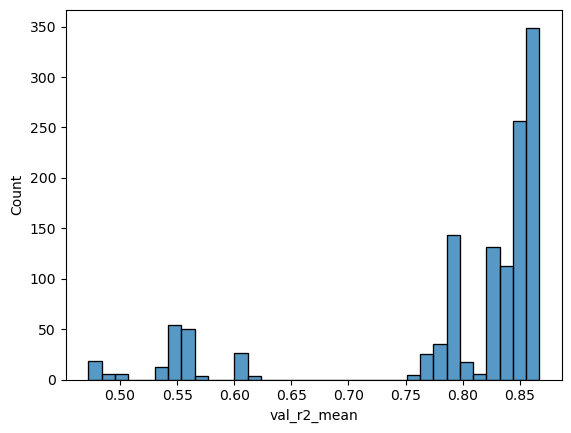

In [62]:
sns.histplot(data=round1_snow[round1_snow.min_child_weight == 0], x='val_r2_mean');

So, it seems a plausible range of `min_child_weight` to hone in on is $[0,50]$. The $1000$ and $500$ values have really low $R^{2}$ for all other hyperparam combos, and $100$ comes close, but the highest the $R^{2}$ gets is smaller than that of $0, 10, 50$. So, let's look at this range.

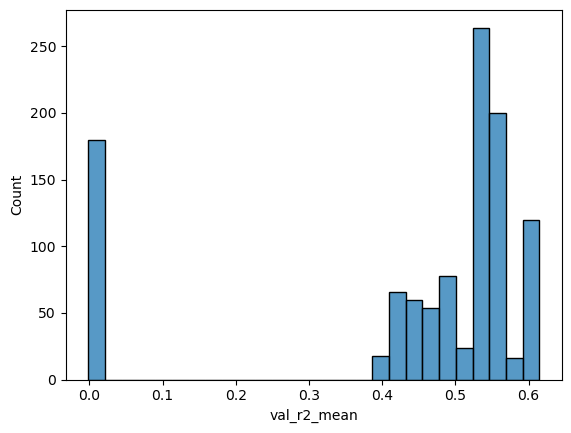

In [70]:
sns.histplot(data=round1_snow[round1_snow.gamma == 100], x='val_r2_mean');

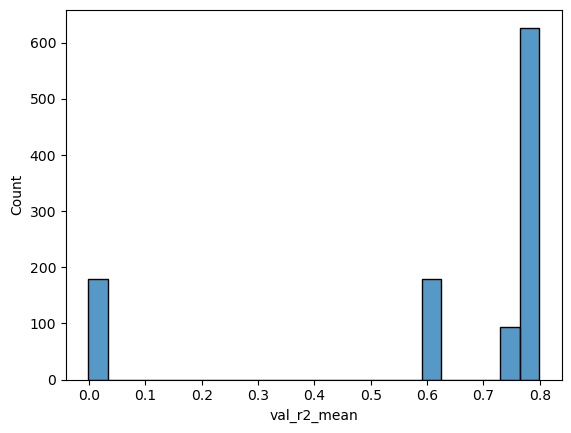

In [71]:
sns.histplot(data=round1_snow[round1_snow.gamma == 10], x='val_r2_mean');

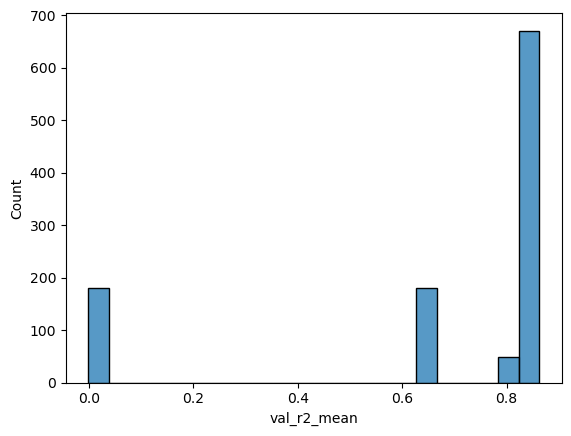

In [72]:
sns.histplot(data=round1_snow[round1_snow.gamma == 1], x='val_r2_mean');

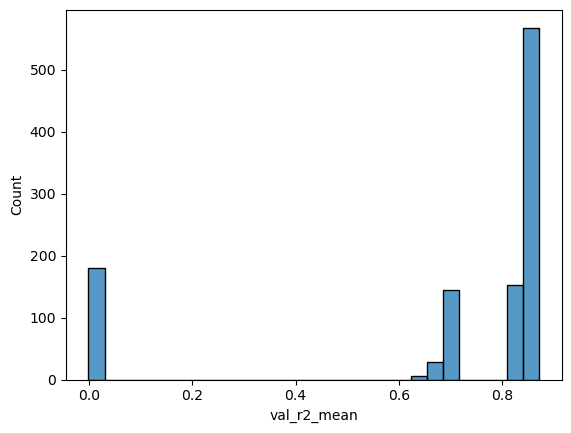

In [73]:
sns.histplot(data=round1_snow[round1_snow.gamma == 0.01], x='val_r2_mean');

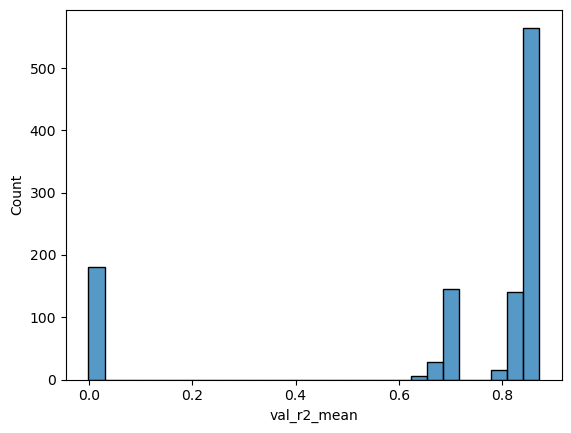

In [79]:
sns.histplot(data=round1_snow[round1_snow.gamma == 0], x='val_r2_mean');

For $\gamma$, let's try $[0,1]$. For other combos, the best we can do is relatively bad in comparison.

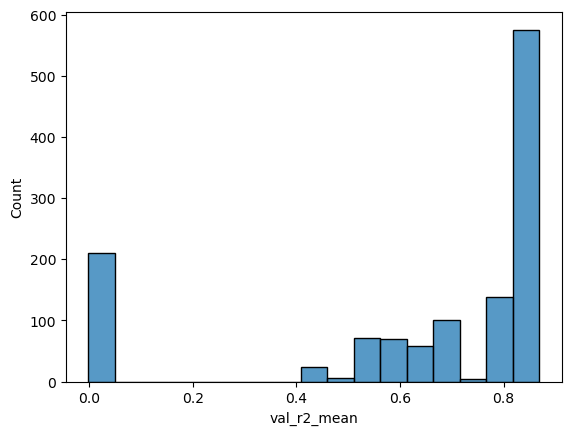

In [91]:
sns.histplot(data=round1_snow[round1_snow.reg_lambda == 0.001], x='val_r2_mean');

It seems like $\lambda$, the $L^{2}$ penalty on weights, can achieve near max performance for all values chosen, but particularly for values at 10 and greater. $0.1$ and smaller and the best performing set was worse. So, let's do $1$ to $100$.

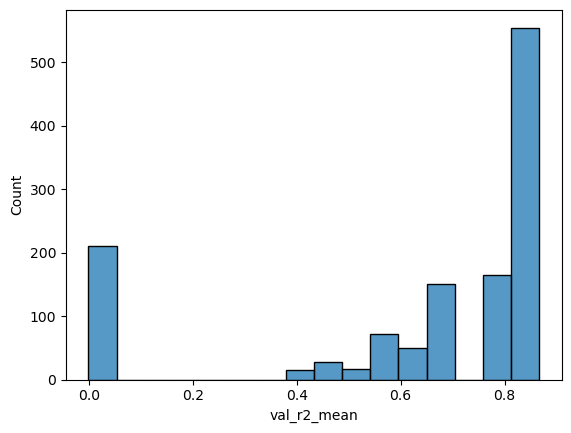

In [102]:
sns.histplot(data=round1_snow[round1_snow.max_depth == 15], x='val_r2_mean');

Seems like `max_depth` does best at values from $3$ and $5$. The best it can do for $7$, $10$, and $15$ are comparable, but slightly worse than for $3$ and $5$. So, let's stick with ranges from $3$ to $7$.

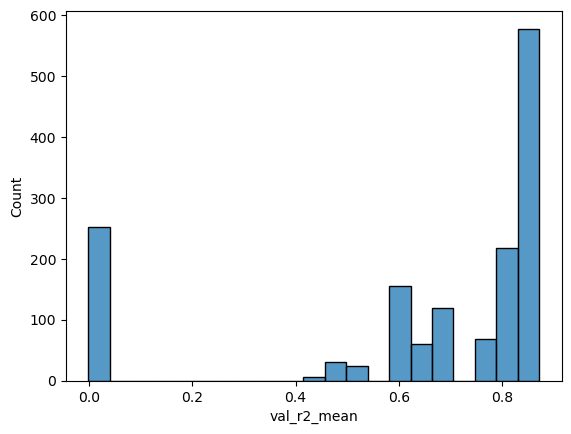

In [122]:
sns.histplot(data=round1_snow[round1_snow.eta == 0.3], x='val_r2_mean');

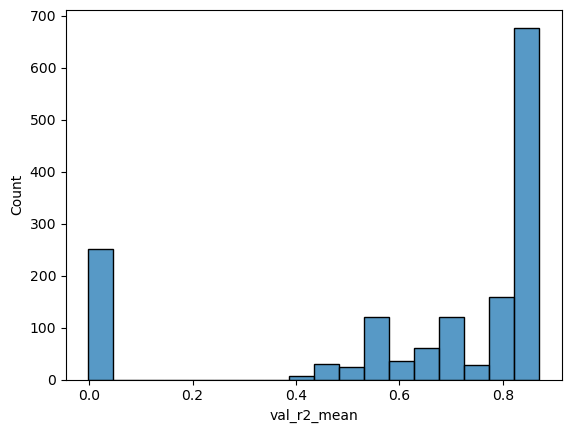

In [132]:
sns.histplot(data=round1_snow[round1_snow.eta == 0.1], x='val_r2_mean');

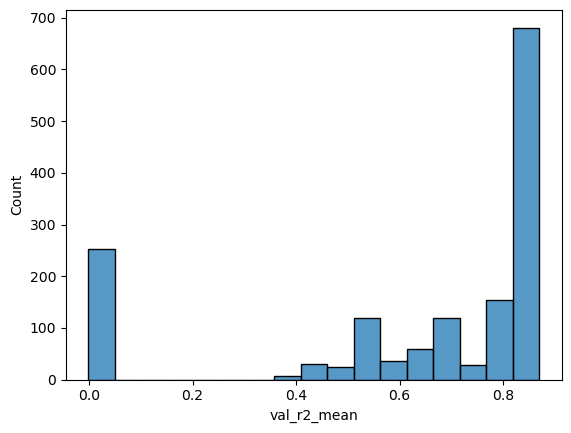

In [133]:
sns.histplot(data=round1_snow[round1_snow.eta == 0.01], x='val_r2_mean');

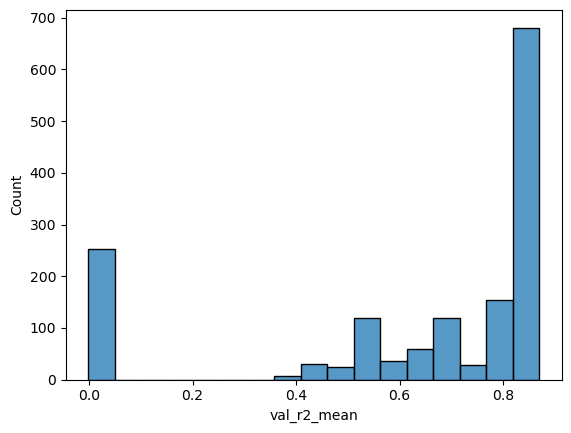

In [134]:
sns.histplot(data=round1_snow[round1_snow.eta == 0.001], x='val_r2_mean');

It seems like most values of $\eta$ perform similarly. We'll keep it the same.

In [145]:
#there are some getting cut off, let's keep this in mind

round1_snow[round1_snow.num_boost == 19999]

,Unnamed: 0,gamma,max_depth,reg_lambda,min_child_weight,eta,num_boost,val_rmse_mean,val_r2_mean,test-r2-mean-ols
14,14,0.0,5.0,0.001,500.0,0.001,19999.0,0.345355,0.687190,0.832548
44,44,0.0,5.0,0.010,500.0,0.001,19999.0,0.345354,0.687192,0.832548
74,74,0.0,5.0,0.100,500.0,0.001,19999.0,0.345363,0.687175,0.832548
124,124,0.0,1.0,0.000,500.0,0.001,19999.0,0.362797,0.654797,0.832548
204,204,0.0,3.0,0.000,500.0,0.001,19999.0,0.345368,0.687168,0.832548
...,...,...,...,...,...,...,...,...,...,...
7514,7514,100.0,15.0,0.010,50.0,0.001,19999.0,0.417309,0.543405,0.832548
7519,7519,100.0,15.0,0.010,100.0,0.001,19999.0,0.417780,0.542427,0.832548
7523,7523,100.0,15.0,0.010,500.0,0.010,19999.0,0.468183,0.425127,0.832548
7524,7524,100.0,15.0,0.010,500.0,0.001,19999.0,0.468560,0.424231,0.832548


### Round 2: Snow

In [4]:
round2_snow = pd.read_csv('rounds/snow_xgb_round2.csv', index_col=False)

In [13]:
with open('rounds/snow_round2_hyperparams.json', 'r') as f:
    json_data = json.load(f)

display(JSON(json_data))

<IPython.core.display.JSON object>

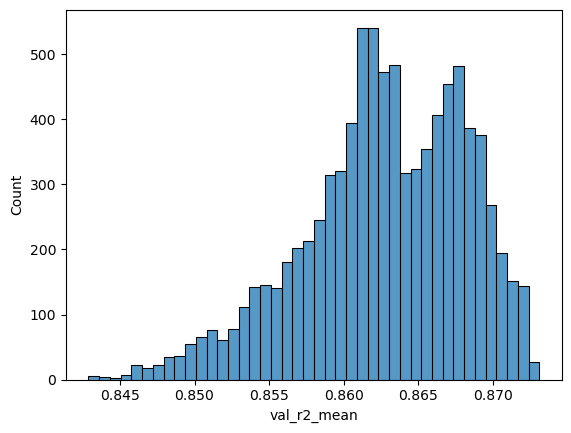

In [12]:
sns.histplot(data=round2_snow, x='val_r2_mean');

`min_child_weight` seems to be best between $[10, 35]$.

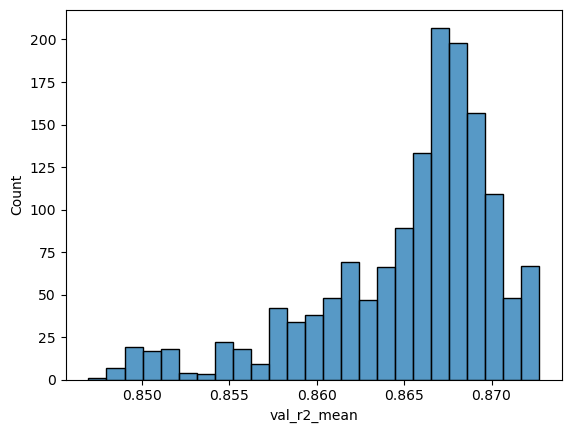

In [5]:
sns.histplot(data=round2_snow[round2_snow.min_child_weight == 25], x='val_r2_mean');

$\lambda$ seems to be best between $[5, 25]$, so let's narrow our search between here.

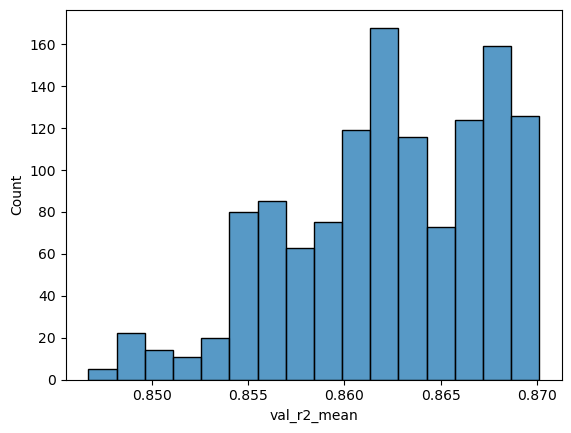

In [60]:
sns.histplot(data=round2_snow[round2_snow.reg_lambda == 50], x='val_r2_mean');

For $\gamma$, $1$ and $0.5$ seem too big, but the other values look comparable. So, let's do $[0,0.1]$.

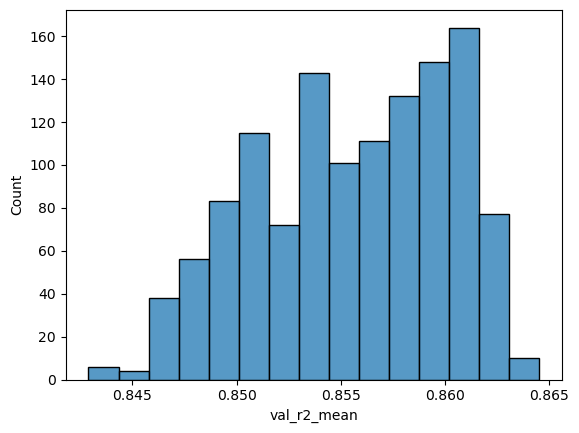

In [71]:
sns.histplot(data=round2_snow[round2_snow.gamma == 1], x='val_r2_mean');

For `max_depth`, $4$ and $5$ seem to be performing the best.

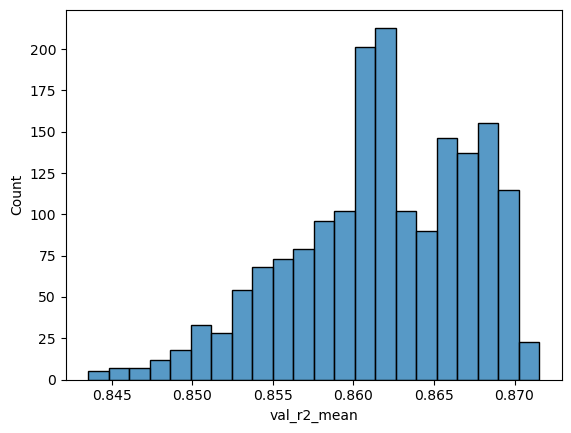

In [77]:
sns.histplot(data=round2_snow[round2_snow.max_depth == 7], x='val_r2_mean');

For $\eta$, it seems the original range is good, but that $0.4$ is too high (the best it can do seems worse than the other options).

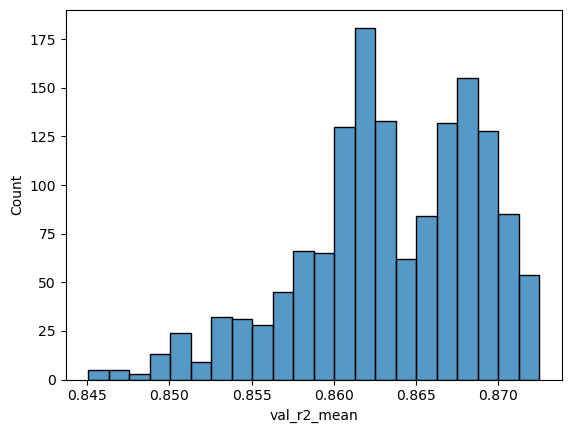

In [91]:
sns.histplot(data=round2_snow[round2_snow.eta == 0.001], x='val_r2_mean');

There are a couple of hyperparam combos in this set which reach the maximum number of boosting iterations. However, it's not that many (only 4). Out of curiosity, we can up the max number of boosting iterations and see if we can get higher.

In [100]:
low_lr = round2_snow[round2_snow.eta == 0.001]
low_lr[low_lr.num_boost == 19999]

,Unnamed: 0,gamma,max_depth,reg_lambda,min_child_weight,eta,num_boost,val_rmse_mean,val_r2_mean,test-r2-mean-ols
1523,1523,0.0001,4.0,100.0,50.0,0.001,19999.0,0.228133,0.863545,0.832548
3233,3233,0.0010,3.0,100.0,10.0,0.001,19999.0,0.223228,0.869319,0.832548
4247,4247,0.0100,3.0,100.0,5.0,0.001,19999.0,0.226281,0.865598,0.832548
4253,4253,0.0100,3.0,100.0,10.0,0.001,19999.0,0.223228,0.869322,0.832548


Between round 1 and round 2, we had a slight improvement..

In [103]:
round1_snow.val_r2_mean.max()

np.float64(0.8721760535479902)

In [104]:
round2_snow.val_r2_mean.max()

np.float64(0.8731065183517673)

In [106]:
round1_snow.iloc[round1_snow.val_r2_mean.idxmax()]

Unnamed: 0          3925.000000
gamma                  0.010000
max_depth              5.000000
reg_lambda            10.000000
min_child_weight      10.000000
eta                    0.300000
num_boost             16.000000
val_rmse_mean          0.220780
val_r2_mean            0.872176
test-r2-mean-ols       0.832548
Name: 3925, dtype: float64

In [108]:
round2_snow.iloc[round2_snow.val_r2_mean.idxmax()]

Unnamed: 0          231.000000
gamma                 0.000000
max_depth             4.000000
reg_lambda           10.000000
min_child_weight     35.000000
eta                   0.050000
num_boost           232.000000
val_rmse_mean         0.220078
val_r2_mean           0.873107
test-r2-mean-ols      0.832548
Name: 231, dtype: float64

In [ ]:
sns.histplot(data=round2_snow[round2_snow.eta == 0.001], x='val_r2_mean');

### Round 3 Snow

In [9]:
with open('rounds/snow_round3_hyperparams.json', 'r') as f:
    json_data = json.load(f)

display(JSON(json_data))

<IPython.core.display.JSON object>

In [3]:
round3_snow = pd.read_csv('rounds/snow_xgb_round3.csv', index_col=False)

<Axes: xlabel='val_r2_mean', ylabel='Count'>

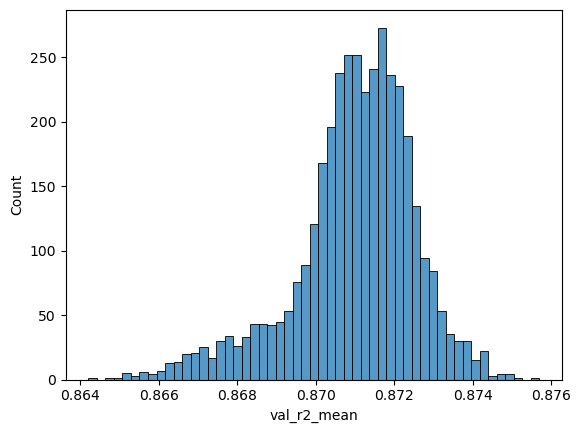

In [4]:
sns.histplot(data=round3_snow, x='val_r2_mean')

In [8]:
# seems like we improved from the last round of searching
round3_snow.loc[round3_snow.val_r2_mean.idxmax()]

Unnamed: 0          3609.000000
gamma                  0.050000
max_depth              5.000000
reg_lambda            17.000000
min_child_weight      15.000000
eta                    0.300000
num_boost             25.000000
val_rmse_mean          0.217806
val_r2_mean            0.875701
test-r2-mean-ols       0.832548
Name: 3609, dtype: float64

Seems like best `min_child_weight` is between $[10,20]$, the best value being at $15$.

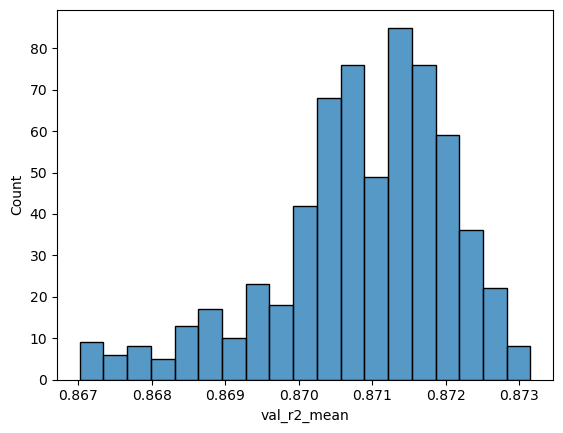

In [21]:
sns.histplot(data=round3_snow[round3_snow.min_child_weight == 35], x='val_r2_mean');

Best $\lambda$ was at $17$, between $[15,20]$ 

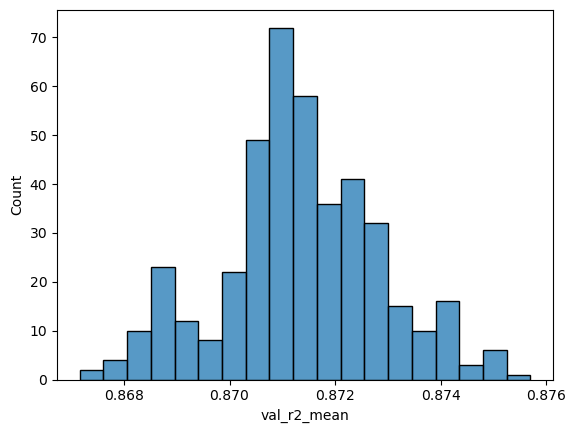

In [31]:
sns.histplot(data=round3_snow[round3_snow.reg_lambda == 17], x='val_r2_mean');

Let's keep both $4$ and $5$ for `max_depth`; it seems like they both perform well.

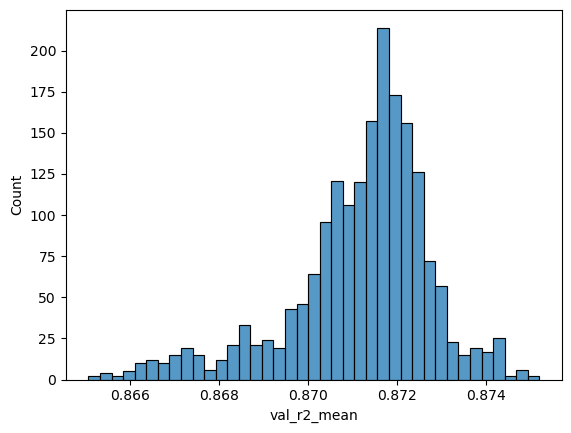

In [39]:
sns.histplot(data=round3_snow[round3_snow.max_depth == 4], x='val_r2_mean');

Best $\gamma$ happens between $[0.01, 0.1]$, with the best value happening at $0.05$.

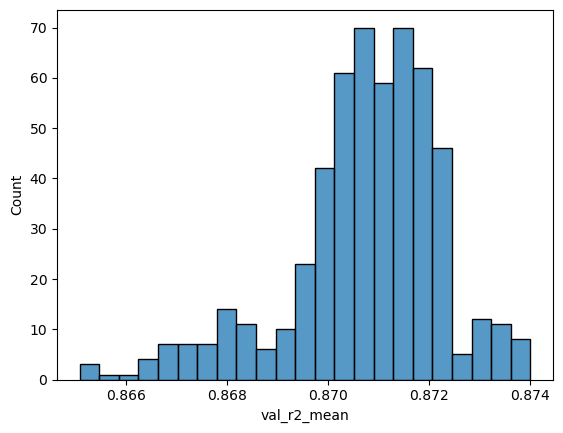

In [46]:
sns.histplot(data=round3_snow[round3_snow.gamma == 0.1], x='val_r2_mean');

Going to keep the same $\eta$.

In [2]:
round4_snow = pd.read_csv('rounds/snow_xgb_round4.csv', index_col=False)

In [5]:
# very very slight improvement from last round..
round4_snow.iloc[round4_snow.val_r2_mean.idxmax()]

Unnamed: 0          19463.000000
gamma                   0.040000
max_depth               5.000000
reg_lambda             16.750000
min_child_weight       14.500000
eta                     0.300000
num_boost              26.000000
val_rmse_mean           0.217751
val_r2_mean             0.875726
test-r2-mean-ols        0.832548
Name: 19463, dtype: float64

### Round 2 Temperature

In [7]:
round2_temp = pd.read_csv('rounds/temp_xgb_round2.csv', index_col=False)

In [11]:
with open('rounds/temp_round2_hyperparams.json', 'r') as f:
    json_data = json.load(f)

display(JSON(json_data))

<IPython.core.display.JSON object>

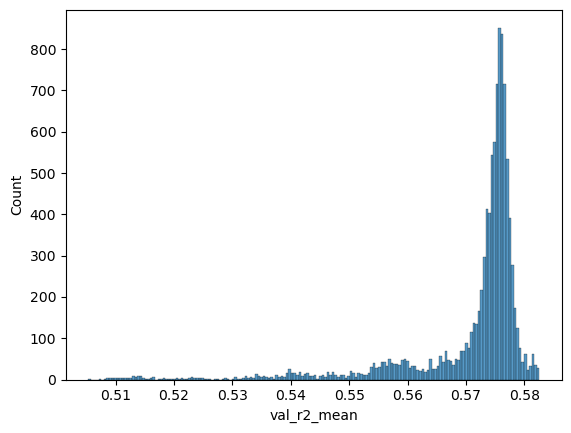

In [8]:
sns.histplot(data=round2_temp, x='val_r2_mean');

In [18]:
round1_temp.val_r2_mean.max()

np.float64(0.5803255270359131)

In [19]:
# slight improvement from round 2
round2_temp.val_r2_mean.max()

np.float64(0.5825760017510397)

Seems like best `min_child_weight` are between $0$ and $25$.

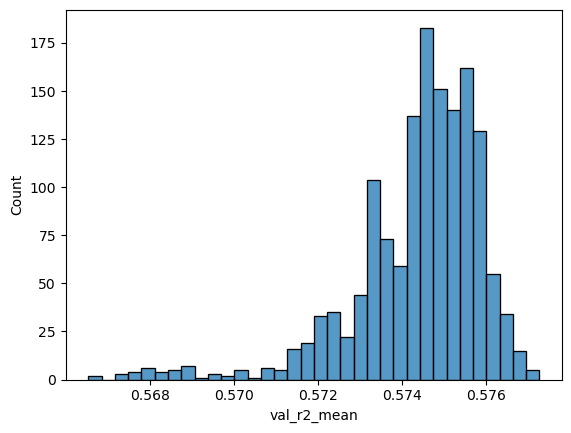

In [25]:
sns.histplot(data=round2_temp[round2_temp.min_child_weight == 100], x='val_r2_mean');

In [ ]:
round2_temp[round2_temp.min_child_weight == 100].max()

Best $\lambda$ between $[0, 10]$

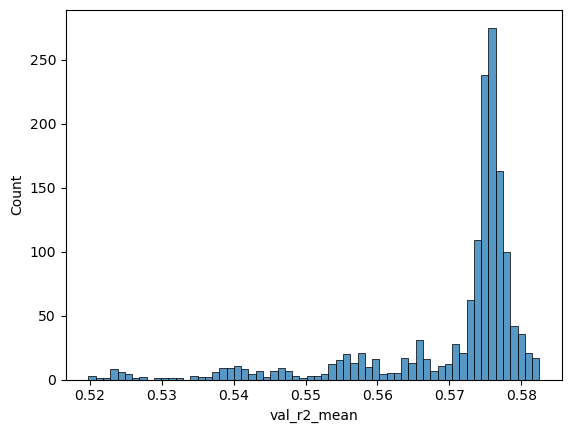

In [50]:
sns.histplot(data=round2_temp[round2_temp.reg_lambda == 1], x='val_r2_mean');

Best $\gamma$ bewteen $[0,10]$

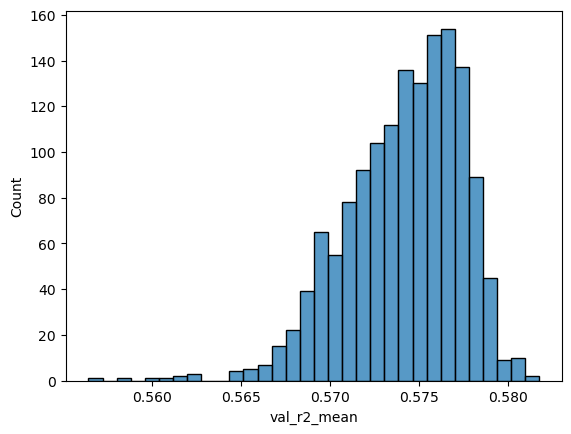

In [57]:
sns.histplot(data=round2_temp[round2_temp.gamma == 100], x='val_r2_mean');

In [67]:
round2_temp[round2_temp.gamma == 100].max()

Unnamed: 0          10289.000000
gamma                 100.000000
max_depth              10.000000
reg_lambda            100.000000
min_child_weight      100.000000
eta                     0.100000
num_boost           19999.000000
val_rmse_mean           5.285397
val_r2_mean             0.581733
test-r2-mean-ols        0.514770
dtype: float64

Best `max_depth` is $5$.

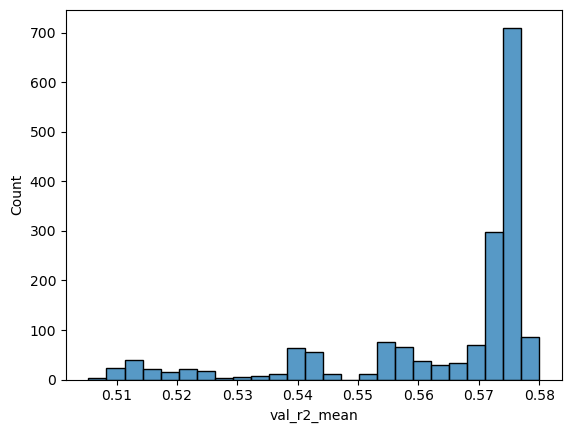

In [73]:
sns.histplot(data=round2_temp[round2_temp.max_depth == 10], x='val_r2_mean');

Best $\eta$ seems to be those except $0.1$.

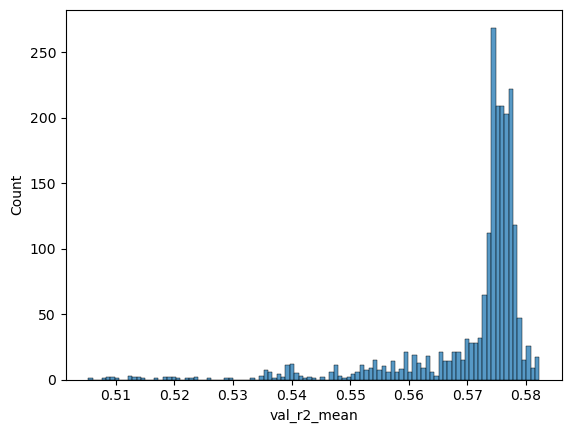

In [79]:
sns.histplot(data=round2_temp[round2_temp.eta == 0.075], x='val_r2_mean');

In [87]:
round2_temp[round2_temp.eta == 0.1].max()

Unnamed: 0          10285.000000
gamma                 100.000000
max_depth              10.000000
reg_lambda            100.000000
min_child_weight      100.000000
eta                     0.100000
num_boost           19999.000000
val_rmse_mean           5.563404
val_r2_mean             0.581750
test-r2-mean-ols        0.514770
dtype: float64

### Round 3 Temperature

In [47]:
round3_temp = pd.read_csv('rounds/temp_xgb_round3.csv', index_col=False)

In [48]:
with open('rounds/temp_round3_hyperparams.json', 'r') as f:
    json_data = json.load(f)

display(JSON(json_data))

<IPython.core.display.JSON object>

In [52]:
# an improvement over the last round
round3_temp.val_r2_mean.max()

np.float64(0.5840907128039314)

In [80]:
round3_temp.loc[round3_temp.val_r2_mean.idxmax()]

Unnamed: 0           48.000000
gamma                 1.000000
max_depth             5.000000
reg_lambda            3.000000
min_child_weight     25.000000
eta                   0.050000
num_boost           104.000000
val_rmse_mean         5.118822
val_r2_mean           0.584091
test-r2-mean-ols      0.514770
Name: 48, dtype: float64

Best `min_child_weight` between $[20, 30]$, with best at $25$

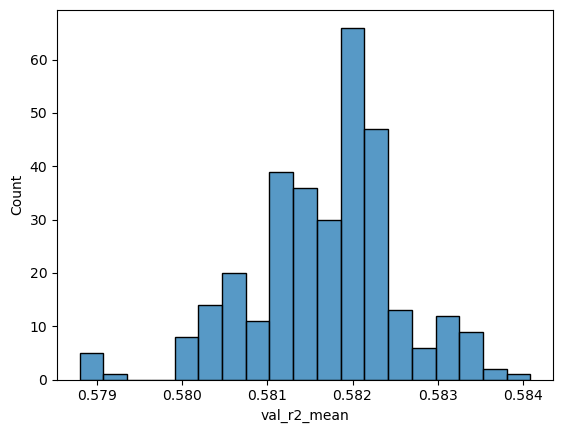

In [59]:
sns.histplot(data=round3_temp[round3_temp.min_child_weight == 25], x='val_r2_mean');

Best $\lambda$ from $[0,7]$

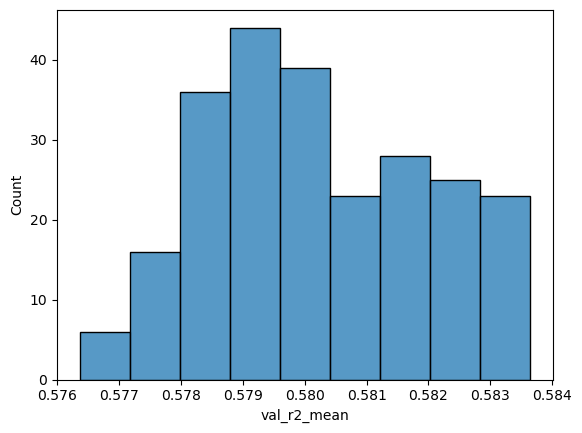

In [71]:
sns.histplot(data=round3_temp[round3_temp.reg_lambda == 5], x='val_r2_mean');

In [76]:
round3_temp[round3_temp.reg_lambda == 1].max()

Unnamed: 0          1719.000000
gamma                 10.000000
max_depth              5.000000
reg_lambda             1.000000
min_child_weight      25.000000
eta                    0.075000
num_boost            618.000000
val_rmse_mean          5.171322
val_r2_mean            0.583382
test-r2-mean-ols       0.514770
dtype: float64

Highest $\gamma$ at $1$, so between $[0.1, 5]$ would be good to test.

In [93]:
round3_temp[round3_temp.gamma == 1].max()

Unnamed: 0          739.000000
gamma                 1.000000
max_depth             5.000000
reg_lambda           10.000000
min_child_weight     25.000000
eta                   0.075000
num_boost           601.000000
val_rmse_mean         5.178265
val_r2_mean           0.584091
test-r2-mean-ols      0.514770
dtype: float64

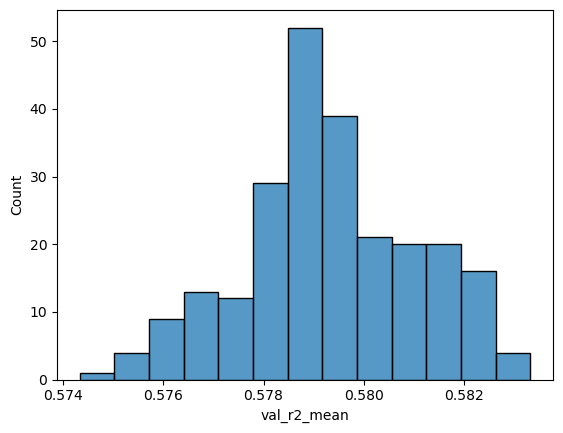

In [82]:
sns.histplot(data=round3_temp[round3_temp.gamma == 0.01], x='val_r2_mean');

Let's keep $\eta$ the same.

In [10]:
with open('rounds/temp_round1_hyperparams.json', 'r') as f:
    json_data = json.load(f)

display(JSON(json_data))

<IPython.core.display.JSON object>

In [16]:
round1_temp = pd.read_csv('rounds/temp_xgb_round1.csv', index_col=False)

In [17]:
round1_temp.val_r2_mean.max()

np.float64(0.5803255270359131)

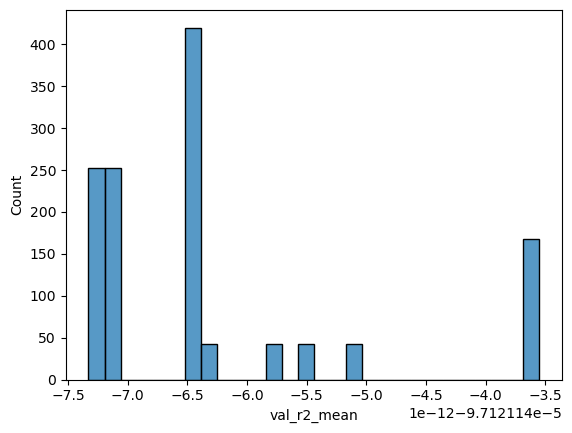

In [158]:
sns.histplot(data=round1_temp[round1_temp.min_child_weight == 1000], x='val_r2_mean');

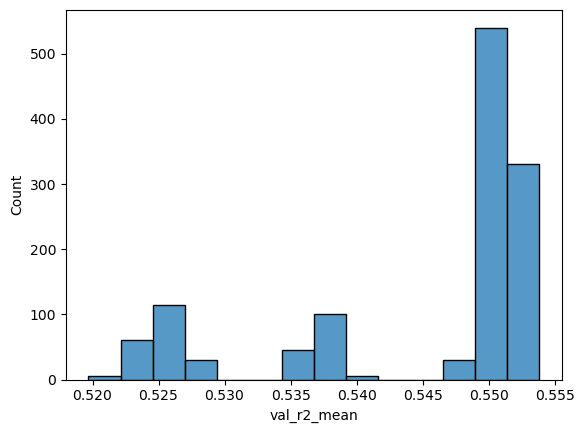

In [160]:
sns.histplot(data=round1_temp[round1_temp.min_child_weight == 500], x='val_r2_mean');

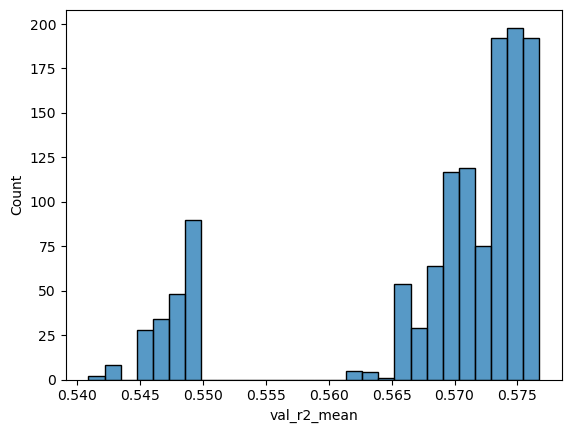

In [167]:
sns.histplot(data=round1_temp[round1_temp.min_child_weight == 100], x='val_r2_mean');

Seems like $[0,100]$ are the best ranges for `min_child_weight`.

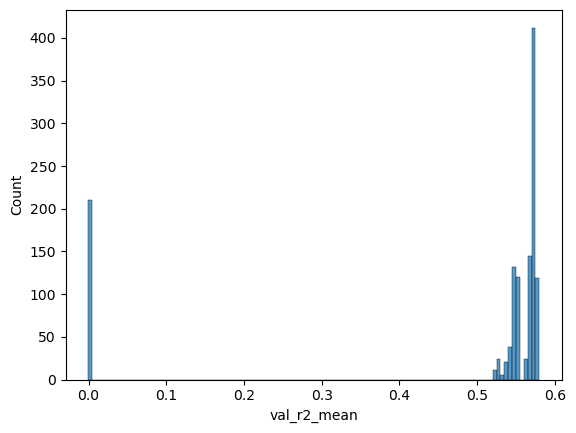

In [188]:
sns.histplot(data=round1_temp[round1_temp.reg_lambda == 100], x='val_r2_mean');

Seems like the full range of $\lambda$ works.

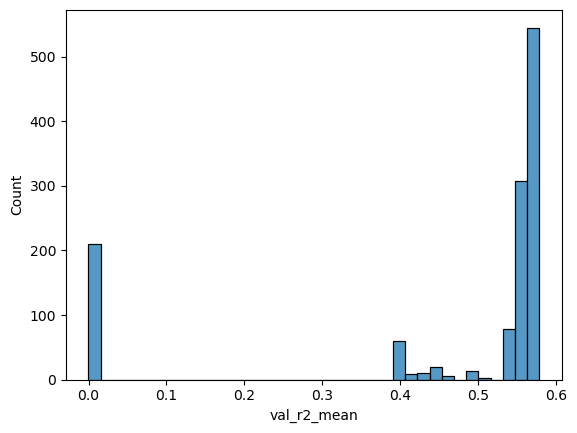

In [205]:
sns.histplot(data=round1_temp[round1_temp.max_depth == 15], x='val_r2_mean');

In [216]:
round1_temp[round1_temp.max_depth == 15].max()

Unnamed: 0           7459.000000
gamma                 100.000000
max_depth              15.000000
reg_lambda            100.000000
min_child_weight     1000.000000
eta                     0.300000
num_boost           19999.000000
val_rmse_mean           7.944224
val_r2_mean             0.578668
test-r2-mean-ols        0.514770
dtype: float64

Max depth: $5, 7, 10$

Seems like all values of gamma work..

In [250]:
round1_temp[round1_temp.eta == 0.3].max()

Unnamed: 0           7555.000000
gamma                 100.000000
max_depth              15.000000
reg_lambda            100.000000
min_child_weight     1000.000000
eta                     0.300000
num_boost           19999.000000
val_rmse_mean           7.944224
val_r2_mean             0.576331
test-r2-mean-ols        0.514770
dtype: float64

For $\eta$, seems like $0.1, 0.05, 0.01$ are the best..

In [46]:
best_performers = round1_snow.loc[round1_snow.val_r2_mean.idxmax()]
best_performers

Unnamed: 0          3925.000000
gamma                  0.010000
max_depth              5.000000
reg_lambda            10.000000
min_child_weight      10.000000
eta                    0.300000
num_boost             16.000000
val_rmse_mean          0.220780
val_r2_mean            0.872176
test-r2-mean-ols       0.832548
Name: 3925, dtype: float64

### Round 4

In [6]:
round4_temp = pd.read_csv('rounds/temp_xgb_round4.csv', index_col=False)

In [9]:
# slight improvement from last round
round4_temp.iloc[round4_temp.val_r2_mean.idxmax()]

Unnamed: 0          6843.000000
gamma                  0.797895
max_depth              5.000000
reg_lambda             2.947368
min_child_weight      24.210526
eta                    0.050000
num_boost            117.000000
val_rmse_mean          5.113155
val_r2_mean            0.584995
test-r2-mean-ols       0.514770
Name: 6843, dtype: float64